<img src="images\Logo_UCLL_ENG_RGB.png" style="background-color:white;" />

# Data Analytics & Machine learning

Lecturers: Aimée Lynn Backiel, Lies Bollens, Fien Van de Woestijne

Academic year 2026-2027

## Lab 2: Data analytics with Pandas

### Recap of last lab(s)

#### Lab 1

1. We ensured we had a valid Python installation.
2. We learnt what a virtual environment is:
   * Isolated Python executable and packages.
   * We created a virtual environment.
3. Absolute path vs relative path recap.
4. Recap of data structures in Python

#### Lab 2
1. Installed Pandas
2. Learnt how to read data
3. Learnt how to calculate mean, mode, median etc.
4. Basic exploration of the 4 variables
5. Bivariate exploration

### The case

Ada Turing Travelogue, or as everyone calls her, Ada just started working part time at her parents travel agency. She has a keen understanding and interest of everything related to applied computer science ranging from server & system management to full stack software development. Through database foundations she already understands how to query data and programming 1 and 2 covered the essentials about the Python programming language. Recently she has just decided to start learning about data analytics & machine learning as well.

She uses her skills to connect to the travel agency's database where she finds many, normalized, tables. Ada recalls what she learnt in database foundations and performs all the correct joins. Afterwards she saves the data in the `data/` folder.


She finds the following dataset:

| Column Name          | Description                                                                                       |
| -------------------- | ------------------------------------------------------------------------------------------------- |
| SalesID              | Unique identifier for each sale.                                                                  |
| Age                  | Age of the traveler.                                                                              |
| Country              | Country of origin of the traveler.                                                                |
| Membership_Status    | Membership level of the traveler in the booking system; could be 'standard', 'silver', or 'gold'. |
| Previous_Purchases   | Number of previous bookings made by the traveler.                                                 |
| Destination          | Travel destination chosen by the traveler.                                                        |
| Stay_length          | Duration of stay at the destination.                                                              |
| Guests               | Number of guests traveling (including the primary traveler).                                             |
| Travel_month         | Month in which the travel is scheduled.                                                           |
| Months_before_travel | Number of months prior to travel that the booking was made.                                       |
| Earlybird_discount   | Boolean flag indicating whether the traveler received an early bird discount.                     |
| Package_Type         | Type of travel package chosen by the traveler.                                                    |
| Cost                 | Calculated cost of the travel package.                                                            |
| Margin | The cost (for the traveler) - what the travel agency pays. |
 | Additional_Services_Cost| The amount of additional services (towels, car rentals, room service, ...) that was bought during the trip. |


### Helping Ada explore the dataset

The main goal for the remainder of this lab is to explore the data. We will specifically take five columns:

* cost
* age
* stay_length
* destination
* country

Our goal is to find interesting relationships between them.

As was covered in the book and lecture there are two main data types in analytics: categorical and numerical data. This is a crucial first step in your analysis because it determines what methods make sense on your data.


**The goal is primarily to find out what influences the cost of the stay.**

### Part 1: Recap from last week

#### Reading and exploring data: univariate

In [137]:
import pandas as pd # by convention
pd.options.display.float_format = '{:.2f}'.format

In [138]:
travel_dataset = pd.read_csv("data/lab_3_dataset.csv")

Let's have a very short refresher of last week's lab. One of the first things you typically do with a dataset is print out the first few rows. 

In [139]:
travel_dataset.head()

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost
0,0,1,47,UK,silver,1,Sydney,4,2,7,1,False,Adventure,1706.09,6,1219.74,291.06
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52
2,2,3,49,USA,standard,2,Sydney,3,4,7,1,False,Cultural,2829.92,6,2360.49,285.36
3,3,4,62,Spain,silver,2,Cape Town,7,2,1,3,True,Adventure,2789.53,7,2315.66,747.53
4,4,5,36,Germany,silver,3,Paris,9,3,2,7,False,Adventure,5358.00,5,5042.14,1117.09


Accessing the columns is equally trivial.

In [140]:
travel_dataset.columns

Index(['Unnamed: 0', 'sales_id', 'age', 'country', 'membership_status',
       'previous_purchases', 'destination', 'stay_length', 'guests',
       'travel_month', 'months_before_travel', 'earlybird_discount',
       'package_Type', 'cost', 'rating', 'margin', 'additional_services_cost'],
      dtype='str')

We can also make subsets like this:

In [141]:
columns = ["country", "stay_length", "age", "cost", "destination"]
travel_dataset_subset = travel_dataset[columns]
travel_dataset_subset

,country,stay_length,age,cost,destination
0,UK,4,47,1706.09,Sydney
1,Italy,4,37,281233.19,Tokyo
2,USA,3,49,2829.92,Sydney
3,Spain,7,62,2789.53,Cape Town
4,Germany,9,36,5358.00,Paris
...,...,...,...,...,...
9995,Germany,11,59,7504.78,Cape Town
9996,Australia,6,18,1427.12,Sydney
9997,USA,5,29,3458.86,Paris
9998,USA,16,47,18392.27,Paris


##### ❓ Summarize all the numerical variables with one line of code. Write down everything you notice about the variable cost.

In [142]:
#YOUR CODE HERE
travel_dataset_subset[["age", "cost", "stay_length"]].describe()

,age,cost,stay_length
count,10000.00,10000.00,10000.00
mean,39.98,114814.74,10.49
std,14.00,457712.61,7.05
min,18.00,-1000000.00,1.00
25%,29.00,2414.47,5.00
50%,39.00,4845.14,9.00
75%,50.00,10222.98,14.00
max,80.00,6724039.17,68.00


YOUR OBSERVATIONS HERE

Cost not as expected, minimum is negative, max is very very large.

##### ❓ Summarize one of the categorical variables.

In [143]:
#YOUR CODE HERE
travel_dataset_subset["country"].describe()

count     10000
unique        8
top          UK
freq       1320
Name: country, dtype: object

**Observations**: Some observations...

### Part 2: Data exploration - bivariate


Now we will look at pairs of variables, to see if we find any interesting relations between two variables. This analysis takes multiple steps.
1) First, you decide which two variables might be interesting to look at together
2) Second, you have to decide upon a technique for analysis. This technique will differ depending on the type of variable. The different combinations are: two numerical variables, two categorical variables and one categorical and one numerical variable. 
3) Depending on the type of variables, you can carry out different analysis. We will explore this below, with one example for each type, to give you an idea of what different analysis looks like for different types of variables. 

Later, when you encounter two other variables you want to analyse, you can use these examples as a blueprint to start carrying out the correct analysis. 

##### ❓ Which variables do you think are interesting to take a look at together?  Write a short motivation on why you would like to look at them and why you chose this technique to analyse this. Then carry out the proper analysis. Choose at least three different combinations: two categorical, two numerical, and one categorical and a numerical variable. Don't lose sight of what we are trying to figure out: what influences the cost of the stay. End your answer with what you observe from your analysis.



**Interesting things to look at:** age and package_Type, age and membership_status, membership_status and package_Type, age and destination, stay_length and travel_month

##### 1) Two numerical variables:
- Why do you look at them? 
- What technique do you use and why? 


YOUR MOTIVATION HERE

In [144]:
#YOUR CODE HERE
# we look at age and cost
travel_dataset_subset[["age", "cost"]].corr()

,age,cost
age,1.00,0.03
cost,0.03,1.00


At the lower ages there seem to be higher standard deviations with the exception of age 80.

##### 2) One numerical variable and one categorical variable: 

- Why do you look at them? 
- What technique do you use and why? 

YOUR MOTIVATION HERE

In [145]:
#YOUR CODE HERE
travel_dataset_subset[["country", "age"]].groupby("country").describe()

age                                          
            count  mean   std   min   25%   50%   75%   max
country                                                    
Australia 1222.00 39.73 13.78 18.00 29.00 40.00 49.00 80.00
Canada    1214.00 39.92 14.10 18.00 29.00 40.00 50.00 80.00
France    1266.00 40.43 14.10 18.00 30.00 40.00 50.00 80.00
Germany   1172.00 40.59 13.93 18.00 30.00 40.00 50.00 80.00
Italy     1274.00 39.57 13.92 18.00 29.00 39.00 49.00 80.00
Spain     1265.00 39.82 13.79 18.00 29.00 39.00 49.00 80.00
UK        1320.00 39.92 14.12 18.00 28.00 40.00 49.00 80.00
USA       1267.00 39.86 14.25 18.00 29.00 40.00 49.00 80.00

YOUR OBSERVATIONS HERE

No real differences between countries in terms of age.

##### 3 ) Two categorical variables:

This analysis will follow the same structure as before. Now, it's up to you to create your own markdown and code cells. 

##### ❓ Extra: I'd like to study age and cost using the groupby method. Is that a good idea? Explain why or why not. If not, do you see a way to make it work?




YOUR EXPLANATION HERE

This might be a good idea, if you want to see if costs will rise with age or not.

In [146]:
#YOUR CODE SOLUTION HERE
travel_dataset["age_group"] = pd.cut(travel_dataset["age"], bins=[0, 25, 35, 45, 55, 65, 100], labels=["under 25", "25-35", "35-45", "45-55", "55-65", "65+"])
travel_dataset[["age_group", "cost"]].groupby("age_group").describe()

cost                                                           \
            count      mean       std         min     25%     50%      75%   
age_group                                                                    
under 25  1761.00 110805.69 436020.88 -1000000.00 2360.21 4812.52 10183.78   
25-35     2192.00  95544.31 449076.29 -1000000.00 2312.77 4768.29  9585.55   
35-45     2620.00 114321.92 463454.22 -1000000.00 2552.40 4905.14 10149.21   
45-55     1987.00 131758.85 488789.52 -1000000.00 2510.94 4967.85 10528.39   
55-65     1031.00 118107.15 431434.71 -1000000.00 2697.60 5430.91 10883.29   
65+        409.00 147894.18 463701.22      196.74 2348.86 4814.27 11212.30   

                      
                 max  
age_group             
under 25  4493769.17  
25-35     6724039.17  
35-45     6057070.02  
45-55     4587735.69  
55-65     3259401.51  
65+       3367020.44

##### ❓ If you have not done so before, analyze cost per destination. Do you notice any abnormal results?


In [147]:
#YOUR CODE HERE
travel_dataset[["destination", "cost"]].groupby("destination").describe()

cost                                                      \
              count      mean       std         min       25%       50%   
destination                                                               
Cairo       1271.00  -3599.38  97458.54 -1000000.00   2307.13   4216.37   
Cape Town   1224.00  -7622.93 114350.91 -1000000.00   2100.42   4102.03   
New York    1229.00  -2176.54  90572.01 -1000000.00   2210.10   4534.42   
Paris       1259.00  -3527.71  97920.70 -1000000.00   2448.66   4656.95   
Rio         1293.00  -4781.88 100440.10 -1000000.00   2056.32   3961.99   
Rome        1197.00  -3456.09  96146.58 -1000000.00   2224.64   4209.89   
Sydney      1275.00  -4994.68 101119.97 -1000000.00   2040.86   3989.17   
Tokyo       1252.00 947170.23 901159.24 -1000000.00 350691.29 706551.82   

                                   
                   75%        max  
destination                        
Cairo          7571.49   43707.46  
Cape Town      7254.45   30977.86  
New York       8052.16   50263.48  
Paris          7665.20   48416.78  
Rio            7103.26   41355.67  
Rome           7605.61   56969.50  
Sydney         7127.65   36791.09  
Tokyo       1254854.24 6724039.17

YOUR OBSERVATIONS HERE

Yes, the mean is negative as is the minimum cost for **each** country (however the mean is not negative for Tokyo this due to the fact that the max is nearly 7 million whatever units, so this pulls up the mean by quite a bit).

##### ❓ How would you deal with this?

YOUR ANSWER HERE

I guess the data has to be 'cleaned', so we delete negative values.

### Part 3:  Subsetting and cleaning data

Ada gets confirmation from her contacts that the data has some issues. The booking system broke down and produced large negative values. Additionally, the currency converter for Tokyo is giving incorrect results.

We will help her rectify these mistakes.

#####  Removing data: boolean indexing

Generally it's a good idea to not alter your original dataset but filter it in a copy. The way Pandas does this is by filtering with a boolean mask. We will demonstrate step by step how to do this.

<center>
<img src="https://numpy.org/doc/stable/_images/broadcasting_1.png" style="background-color:white;">
</center>

The data we want gone are the rows where the cost equals `-1000000.00`. We can check for each row if that's the case. 

Pandas uses a technique called "broadcasting" where if you try to do operations between values of different shapes Pandas will try to expand one to make them match.

This means you don't need to explicitly turn the value into an array of the same size.

In [148]:
non_errors = travel_dataset["cost"] != -1000000.00
non_errors

0       True
1       True
2       True
3       True
4       True
        ... 
9995    True
9996    True
9997    True
9998    True
9999    True
Name: cost, Length: 10000, dtype: bool

❓ Check how many non_errors we have in the dataset

In [149]:
#YOUR CODE HERE
int(non_errors.count())

10000

❓ Is explicitly checking if the cost does not equal -1000000.00 the best way to filter out wrong cost values? Adapt the checking for non_errors to a more logical constraint. See if we still have the same number of errors.

In [150]:
#YOUR CODE HERE
non_errors = travel_dataset["cost"] > 0
#int(non_errors.count())
non_errors

0       True
1       True
2       True
3       True
4       True
        ... 
9995    True
9996    True
9997    True
9998    True
9999    True
Name: cost, Length: 10000, dtype: bool

Pandas allows you to give a boolean array as an index to filter out rows. The rows where the boolean array (also known as a mask) is `True` are kept. 

In [151]:
travel_dataset[non_errors] 

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost,age_group
0,0,1,47,UK,silver,1,Sydney,4,2,7,1,False,Adventure,1706.09,6,1219.74,291.06,45-55
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52,35-45
2,2,3,49,USA,standard,2,Sydney,3,4,7,1,False,Cultural,2829.92,6,2360.49,285.36,45-55
3,3,4,62,Spain,silver,2,Cape Town,7,2,1,3,True,Adventure,2789.53,7,2315.66,747.53,55-65
4,4,5,36,Germany,silver,3,Paris,9,3,2,7,False,Adventure,5358.00,5,5042.14,1117.09,35-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,9996,59,Germany,standard,3,Cape Town,11,3,8,1,True,Adventure,7504.78,7,7045.05,1602.18,55-65
9996,9996,9997,18,Australia,standard,1,Sydney,6,1,7,1,True,Relaxation,1427.12,7,1051.24,395.36,under 25
9997,9997,9998,29,USA,silver,3,Paris,5,3,12,2,True,Adventure,3458.86,5,2945.36,539.41,25-35
9998,9998,9999,47,USA,standard,5,Paris,16,5,8,3,False,Relaxation,18392.27,5,17968.59,5247.25,45-55


We can also combine all of the above in one line, to directly filter out all the values with a faulty cost 

In [152]:
travel_dataset[travel_dataset["cost"] > 0]

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost,age_group
0,0,1,47,UK,silver,1,Sydney,4,2,7,1,False,Adventure,1706.09,6,1219.74,291.06,45-55
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52,35-45
2,2,3,49,USA,standard,2,Sydney,3,4,7,1,False,Cultural,2829.92,6,2360.49,285.36,45-55
3,3,4,62,Spain,silver,2,Cape Town,7,2,1,3,True,Adventure,2789.53,7,2315.66,747.53,55-65
4,4,5,36,Germany,silver,3,Paris,9,3,2,7,False,Adventure,5358.00,5,5042.14,1117.09,35-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,9996,59,Germany,standard,3,Cape Town,11,3,8,1,True,Adventure,7504.78,7,7045.05,1602.18,55-65
9996,9996,9997,18,Australia,standard,1,Sydney,6,1,7,1,True,Relaxation,1427.12,7,1051.24,395.36,under 25
9997,9997,9998,29,USA,silver,3,Paris,5,3,12,2,True,Adventure,3458.86,5,2945.36,539.41,25-35
9998,9998,9999,47,USA,standard,5,Paris,16,5,8,3,False,Relaxation,18392.27,5,17968.59,5247.25,45-55


##### ❓Create a new dataset called `_dataset_cleaned` , which contains only the rows with a non faulty value. Make a copy of the original dataset, such that we do not accidentally alter values in the original dataset 

In [153]:
#YOUR CODE HERE
_dataset_cleaned = travel_dataset[travel_dataset["cost"] > 0]

##### ❓ Make a mask for the people that traveled to Tokyo. Call the variable `tokyo`.

In [154]:
#YOUR CODE HERE
tokyo = _dataset_cleaned["destination"] == "Tokyo"
tokyo

0       False
1        True
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: destination, Length: 9900, dtype: bool

#####  Updating rows the right way

We can now grab the rows where the destination is Tokyo as follows

In [155]:
_dataset_cleaned[tokyo]

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost,age_group
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52,35-45
6,6,7,63,Italy,silver,4,Tokyo,1,1,6,1,False,Cultural,37424.42,7,-89.33,81.53,55-65
7,7,8,51,Spain,silver,3,Tokyo,11,2,7,3,True,Adventure,810452.74,5,4882.30,1509.58,45-55
11,11,12,33,Australia,standard,3,Tokyo,4,3,7,5,True,Adventure,445455.58,7,2574.81,738.01,25-35
27,27,28,45,Spain,silver,4,Tokyo,19,3,2,11,True,Relaxation,1796515.55,6,11144.05,3772.01,35-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9936,9936,9937,44,Australia,gold,5,Tokyo,2,2,8,14,True,Cultural,143747.78,8,798.81,123.23,35-45
9958,9958,9959,49,Australia,standard,1,Tokyo,9,1,8,3,False,Adventure,320119.76,6,1727.44,702.34,45-55
9965,9965,9966,47,Spain,standard,2,Tokyo,5,2,2,1,False,Adventure,324200.00,5,1661.63,494.94,45-55
9986,9986,9987,34,Italy,standard,3,Tokyo,5,3,12,8,False,Relaxation,535010.48,6,3011.18,875.61,25-35


This gives us a filtered dataset of all people that traveled to Tokyo, with the faulty values already removed.
We can take a look at the cost column as follows

In [156]:
_dataset_cleaned[tokyo]["cost"]

1       281233.19
6        37424.42
7       810452.74
11      445455.58
27     1796515.55
          ...    
9936    143747.78
9958    320119.76
9965    324200.00
9986    535010.48
9991     67273.96
Name: cost, Length: 1239, dtype: float64

Now we have the rows we can convert the currency by dividing by 158, to get the correct price. 
You will likely try to do this in the following way:

`_dataset_cleaned[tokyo]["cost"] /= 158`

You can try it out below and look at the result

In [157]:
_dataset_cleaned[tokyo]["cost"] /= 158

/var/folders/jg/6dpxbzzn6vv7y0jk1fk2581w0000gn/T/ipykernel_87745/740947496.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  _dataset_cleaned[tokyo]["cost"] /= 158


This gives us the same error as we encountered in the previous session. The way we can get around is is by using `data.loc`.

When we read the error message, it tells us two things: 
1) The abovementioned code currently still works in certain cases, but in the future it will not work anymore. 

*This is a sure sign that we should not use this line of code anymore. If we would, in the future, it might suddenly break and not function anymore. Right now, we know where we are coding and can easily update this line of code. But, in the future, we might have a whole project with 1000s of lines of code. If you then have to look for where exactly the error occurs, you will end up spending a long time doing something not very fun. Think about future you.*

2) to use  `df.loc[row_indexer, "col"] = values` instead, since this will ensure we **keep on updating the original dataframe**. 



`df.loc` can be quite confusing. It is an object you can slice by using square brackets `[]`. The first element is the **index**. This is typically the column on the far left.

In [158]:
_dataset_cleaned.index # Each dataframe has an index, which is shown on the left. It typically starts at 0 and goes to the number of rows - 1.

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       9990, 9991, 9992, 9993, 9994, 9995, 9996, 9997, 9998, 9999],
      dtype='int64', length=9900)

In [159]:
tokyo.index # Each series has an index too

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       9990, 9991, 9992, 9993, 9994, 9995, 9996, 9997, 9998, 9999],
      dtype='int64', length=9900)

In [160]:
_dataset_cleaned.loc[tokyo] # Loc filters the dataset where tokyo is true  

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost,age_group
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52,35-45
6,6,7,63,Italy,silver,4,Tokyo,1,1,6,1,False,Cultural,37424.42,7,-89.33,81.53,55-65
7,7,8,51,Spain,silver,3,Tokyo,11,2,7,3,True,Adventure,810452.74,5,4882.30,1509.58,45-55
11,11,12,33,Australia,standard,3,Tokyo,4,3,7,5,True,Adventure,445455.58,7,2574.81,738.01,25-35
27,27,28,45,Spain,silver,4,Tokyo,19,3,2,11,True,Relaxation,1796515.55,6,11144.05,3772.01,35-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9936,9936,9937,44,Australia,gold,5,Tokyo,2,2,8,14,True,Cultural,143747.78,8,798.81,123.23,35-45
9958,9958,9959,49,Australia,standard,1,Tokyo,9,1,8,3,False,Adventure,320119.76,6,1727.44,702.34,45-55
9965,9965,9966,47,Spain,standard,2,Tokyo,5,2,2,1,False,Adventure,324200.00,5,1661.63,494.94,45-55
9986,9986,9987,34,Italy,standard,3,Tokyo,5,3,12,8,False,Relaxation,535010.48,6,3011.18,875.61,25-35


In [161]:
_dataset_cleaned.loc[tokyo, "cost"]

1       281233.19
6        37424.42
7       810452.74
11      445455.58
27     1796515.55
          ...    
9936    143747.78
9958    320119.76
9965    324200.00
9986    535010.48
9991     67273.96
Name: cost, Length: 1239, dtype: float64

It is a good habit to make a copy before you change your data. If you don't do this and make a mistake you need to rerun your entire script. For a small dataset like this it's not a big problem, but as you scale it can become a bottleneck.

In [162]:
cleaned_dataset = _dataset_cleaned.copy()

In [163]:

cleaned_dataset.loc[tokyo, "cost"] /= 158

In [164]:
_dataset_cleaned

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost,age_group
0,0,1,47,UK,silver,1,Sydney,4,2,7,1,False,Adventure,1706.09,6,1219.74,291.06,45-55
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52,35-45
2,2,3,49,USA,standard,2,Sydney,3,4,7,1,False,Cultural,2829.92,6,2360.49,285.36,45-55
3,3,4,62,Spain,silver,2,Cape Town,7,2,1,3,True,Adventure,2789.53,7,2315.66,747.53,55-65
4,4,5,36,Germany,silver,3,Paris,9,3,2,7,False,Adventure,5358.00,5,5042.14,1117.09,35-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,9996,59,Germany,standard,3,Cape Town,11,3,8,1,True,Adventure,7504.78,7,7045.05,1602.18,55-65
9996,9996,9997,18,Australia,standard,1,Sydney,6,1,7,1,True,Relaxation,1427.12,7,1051.24,395.36,under 25
9997,9997,9998,29,USA,silver,3,Paris,5,3,12,2,True,Adventure,3458.86,5,2945.36,539.41,25-35
9998,9998,9999,47,USA,standard,5,Paris,16,5,8,3,False,Relaxation,18392.27,5,17968.59,5247.25,45-55


We can also give columns or a list of columns to `.loc`. In this case only the rows we ask for will be returned

In [165]:
_dataset_cleaned.loc[tokyo, "cost"]

1       281233.19
6        37424.42
7       810452.74
11      445455.58
27     1796515.55
          ...    
9936    143747.78
9958    320119.76
9965    324200.00
9986    535010.48
9991     67273.96
Name: cost, Length: 1239, dtype: float64

It is a good habit to make a copy before you change your data. If you don't do this and make a mistake you need to rerun your entire script. For a small dataset like this it's not a big problem, but as you scale it can become a bottleneck.


##### ❓ create a new copy of the dataset, called `cleaned_dataset`. Use the df.loc function to divide the cost of the trips to Tokyo by 158. 



In [166]:
#YOUR CODE HERE
cleaned_dataset = travel_dataset_subset.copy()
cleaned_dataset = cleaned_dataset[cleaned_dataset["cost"] > 0]  # filter out negative costs
tokyo = cleaned_dataset["destination"] == "Tokyo"
cleaned_dataset.loc[tokyo, "cost"] /= 158
cleaned_dataset.describe()

,stay_length,age,cost
count,9900.00,9900.00,9900.00
mean,10.49,40.00,5745.25
std,7.05,14.01,5033.58
min,1.00,18.00,94.29
25%,5.00,29.00,2293.16
50%,9.00,39.00,4226.01
75%,14.00,50.00,7559.84
max,68.00,80.00,56969.50


##### ❓We will briefly look at the impact of what we did on our analysis of cost by destination. What effect did our corrections have on the data?

In [167]:
#YOUR CODE HERE
cleaned_dataset[["destination", "cost"]].groupby("destination").describe()

cost                                                        
              count    mean     std    min     25%     50%     75%      max
destination                                                                
Cairo       1259.00 5897.69 5300.76 286.53 2333.22 4342.23 7620.21 43707.46
Cape Town   1208.00 5521.14 4677.70 236.15 2214.01 4132.99 7317.52 30977.86
New York    1219.00 6009.05 5394.53 104.24 2292.23 4576.78 8110.89 50263.48
Paris       1247.00 6061.44 5078.72 169.12 2541.93 4708.07 7703.17 48416.78
Rio         1280.00 5325.80 4614.33 190.22 2085.66 4003.00 7139.52 41355.67
Rome        1186.00 5786.73 5081.94 180.58 2294.48 4234.08 7627.67 56969.50
Sydney      1262.00 5254.98 4355.73 114.02 2141.01 4053.77 7198.85 36791.09
Tokyo       1239.00 6124.05 5591.10  94.29 2293.94 4566.32 8038.30 42557.21

YOUR OBSERVATIONS HERE

##### ❓Compare the correlation between age, cost and stay length before and after data cleaning. What differences do you see?

In [168]:
# Before data cleaning
travel_dataset_subset[["age", "cost", "stay_length"]].corr()

,age,cost,stay_length
age,1.00,0.03,0.00
cost,0.03,1.00,0.22
stay_length,0.00,0.22,1.00


In [169]:
# After data cleaning
cleaned_dataset[["age", "cost", "stay_length"]].corr()

,age,cost,stay_length
age,1.00,0.02,0.00
cost,0.02,1.00,0.75
stay_length,0.00,0.75,1.00


YOUR OBSERVATION HERE


##### ❓ How do we interpret these correlations? Why do you think the correlations changed so much? 

Because the costs for destination Tokyo were substantially reduced by a factor of 158 influencing the correlation.

YOUR EXPLANATION HERE

Extra food for thought: 
- correlation only gives a measure of linear relationships. Low correlations don't always mean an absence of a relationship, it could be there but just non-linear.
- a correlation measures the fact that there is **a** linear relationship. However, how exactly to interpret these numbers is not necessarily straightforward. 


How do we interpret our correlation value of 0.75?

**What correlation does NOT mean**
> If variable A increases with 1 unit variable B increases with 0.75 units.

**Why is this not the interpretation?** 

The (sample) correlation $r_{X,Y}$ is given as:

$$
r_{x,y} = \frac{cov(x,y)}{(n-1)s_{x}s_{y}} = \frac{\sum_{i=1}^{n}{(x_{i} - \bar{x})(y_{i} - \bar{y})}}{(n-1)s_{x}s_{y}}
$$

We have some notation to unpack here.

We have two variables $x$ and $y$. These each have a mean $\bar{x}$ and $\bar{y}$ pronounced as x bar and y bar respectively, $s_{x}$ and $s_{y}$ are respectively the standard deviations of x and y.

The first equality shows us that the correlation $r_{x, y}$ is a normalized version of something called the covariance (cov). The scaling is achieved by dividing by a factor related to the product of the standard deviations of the two variables. This is what ensures that $r_{x,y} \in [-1, 1]$. 

Thee covariance expresses the joint variability of two variables. A covariance of 8 means that if variable x increased by 1 the other variable increases by an amount that is dependent on the units and scale of both variables; it doesn't specify a fixed number of units either.

Thus, the correct interpretation of a correlation coefficient is: 

> A correlation coefficient, measures the strength and direction of a linear relationship between two variables, but not the slope of that relationship.

Finally, to know how much one variable varies in function of the other we can look at the regression slope:

$$
\beta_{y} = r_{x,y}\frac{s_{x}}{s_{y}}
$$

The slope of the regression has a deep connection with the correlation. It's the correlation weighted by the proportion of the standard deviations. Logically, if $s_{x} = s_{y}$ the interpretation given last lecture holds. Generally that is not the case, so those that made this remark last lecture were correct. The equation above shows that it is trivial to recover the slope from the correlation.

It is important to remember that correlations and the slope of a regression are expressing linear relationships. As discussed last lecture Anscombe's quartet consists of four datasets that have nearly identical simple descriptive statistics, yet have very different distributions and appear very different when graphed. **This highlights the importance of visualizing data and not relying solely on statistical metrics.**



<center>
Anscomnbe's quarter: four datasets with an equal correlation.
<br>
<br>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" style="width:50%">
</center>

### Introduction to plotting with Matplotlib, Seaborn and Plotly

We have helped Ada so far to gain insights into her data by wrangling it into shape and making tables to summarize data. Now, to further enhance our understanding and visualize the patterns, trends, and potential anomalies, we will be plotting the data. 

Making data visual simplifies complex datasets and also makes it more intuitive for stakeholders to grasp key takeaways. By transitioning from tabular summaries to graphical plots, we can also communicate more effectively.

#### Matplotlib

<center>
<img src="https://matplotlib.org/stable/_images/sphx_glr_logos2_003.png" style="background-color:white">
</center>

The name matplotlib comes from matrix plotting library. It's a descendant from the MATLAB programming language. It's by now an older library (2003) that has some quirks, but it is still important to know the basics of Matplotlib since other Python plotting libraries build on top of it. 

In [170]:
# uncomment to install
#%pip install matplotlib 

In [171]:
import matplotlib.pyplot as plt # convention


##### Plotting univariate data


The table below is a summary of the different types of plots for **numeric data**.

| Plot Type          | Description                                           | When to Use                                                      |
|--------------------|-------------------------------------------------------|------------------------------------------------------------------|
| **Histogram**      | Displays the distribution of a single continuous variable by dividing the data into bins and showing the frequency of observations in each bin. | To visualize the distribution of a variable, especially to identify its central tendency (mean), spread (standard deviation), and skewness (are low or high values more common).  |
| **Box Plot (or Whisker Plot)** | Shows the distribution of a variable using quartiles and displays potential outliers. | To get a summary of a variable's distribution in terms of its median, quartiles, and possible outliers. Useful when comparing the distribution across categories. |
| **Density Plot (or Kernel Density Plot)** | Provides a smoothed version of a histogram. | To visualize the distribution of a variable in a continuous manner. Particularly useful when comparing the distributions of multiple variables on the same plot. |
| **Violin Plot**    | Combines aspects of box plots and density plots.       | To visualize both the distribution and summary statistics of a variable. Especially useful when comparing across different categories. |


The syntax for plotting is generally `plt.<plotType>(x, y)`. 

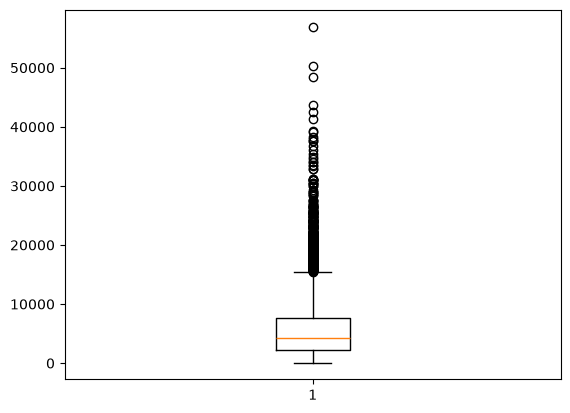

In [172]:

plt.boxplot(cleaned_dataset["cost"]); # Matplotlib prints things while plotting, the semicolon an suppress it.

A boxplot provides a comprehensive view of a dataset's distribution, offering more detailed insights than typical tables. The central line within the box represents the median, splitting the data into its lower and upper halves. The box itself is framed by two lines: the lower boundary represents the 25th percentile (or Q1), meaning 25% of the data lies below this value, and the upper boundary denotes the 75th percentile (or Q3), indicating that 75% of the data is below this point.

The range between Q3 and Q1 is known as the Interquartile Range (IQR). Beyond the box, the plot extends 'whiskers'. Their "distance" is calculated as `1.5 * IQR` both above and below the box, providing a range for typical data points. Any data outside these whiskers can be considered possible outliers.

##### ❓ What can we learn from this boxplot? Try answering the following questions in your response:
* is the data symmetrical, or skewed? How did you see this? What does that mean for the cost variable?
* is there a large spread in the data or not? How did you see this? What does that mean for the cost variable?
* where does most of the data lie? Are there any points that differ significantly from the others?  

YOUR OBSERVATIONS HERE

The data is skewed. There is a pretty large spread if you ask me. There are points (prices) that differ significantly from the others, such as those above 15k...

##### ❓Take a look at the list of possible plots above. Which one would make sense to make when we are just looking at one variable at the time? Figure out the syntax to make this plot and create one for cost. 

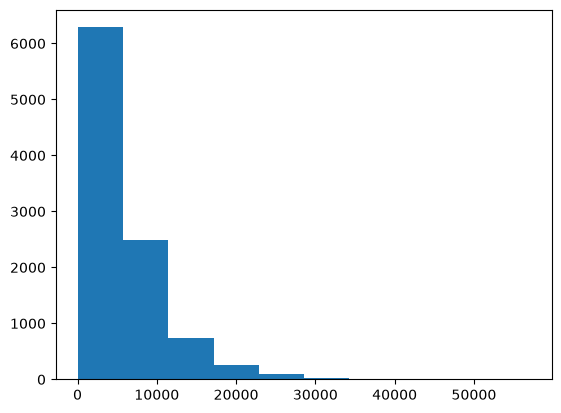

In [173]:
#YOUR CODE HERE
plt.hist(cleaned_dataset["cost"]);

If all goes well, you made a histogram in the figure above. The histogram has a parameter called 'bins'. 

##### ❓Try setting bins to different values. Can you figure out what it does? Try to find a good value for bins for cost.

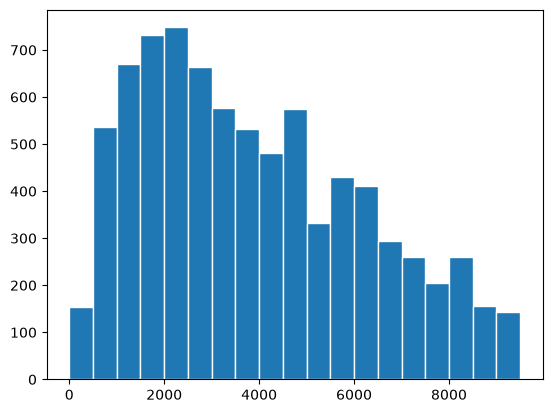

In [174]:
#YOUR CODE HERE
plt.hist(cleaned_dataset["cost"], bins=[x for x in range(0, 10000, 500)], edgecolor="white");

##### ❓How would you interpret this histogram? Use the same questions as with the boxplot to formulate your answer

Most costs are located around $2000 (unit dolars I guess?). There is quite a significant spread in the results not to mention that the results are skewed.

YOUR INTERPRETATION HERE

##### ❓Now make both of these figures again for age and interpret the results. You can write one conclusion in which you discuss both plots at ones if you prefer. Make sure to describe WHAT you see and WHERE you see it on the plot. (This time, make your own code and markdown boxes again.)

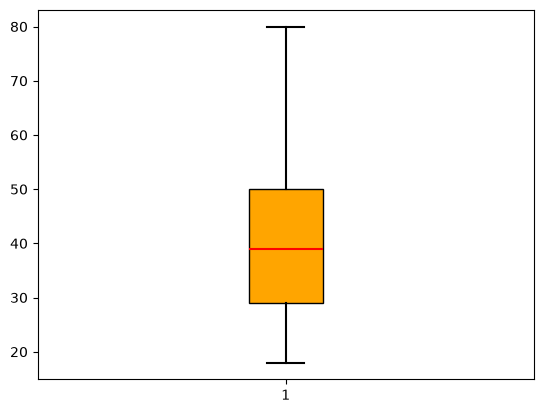

In [175]:
# Boxplot for age
plt.boxplot(cleaned_dataset["age"], patch_artist=True,
                showmeans=False, showfliers=False,
                medianprops={"color": "red", "linewidth": 1.5},
                boxprops={"facecolor": "orange", "edgecolor": "black",
                          "linewidth": 1.0},
                whiskerprops={"color": "black", "linewidth": 1.5},
                capprops={"color": "black", "linewidth": 1.5});

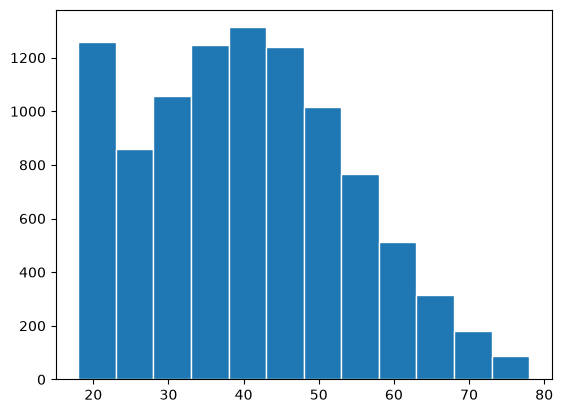

In [176]:
# Histogram for age
plt.hist(cleaned_dataset["age"], bins=[x for x in range(18, 80, 5)], edgecolor="white");

For categorical data, categories can often serve as a basis for comparison in other plots, like boxplots. This means you can use a single category to differentiate data within such plots. You can also produce the same type of plot multiple times, once for each category, to analyze patterns within individual categories.


| Plot Type     | Description                                          | When to Use                                         |
|---------------|------------------------------------------------------|-----------------------------------------------------|
| **Count Plot**| Represents the frequency or count of each category.  | To see how often each category appears in the data. |

Count plots require an additional package, called seaborn. We will learn how to make plots with seaborn in the next lab.